# NIH Chest X-Ray: Multi-Label Disease Classification Pipeline

**Goal:** Build a reproducible pipeline that diagnoses up to 14 thoracic pathologies
(multi-label) from chest X-rays, combining tabular metadata and image data.

The notebook addresses the following 12 tasks:

| Task | Description | Section |
|---|---|---|
| 1 | Explore dataset, identify missing values, % missing per feature | §2 |
| 2 | Decide on missing-data strategy and justify it | §3 |
| 3 | Implement the chosen method, evaluate its impact | §4 |
| 4 | Explore dataset, identify potential features | §5 |
| 5 | Implement feature engineering to create new features | §6 |
| 6 | Evaluate impact of new features on model performance | §7 |
| 7 | Identify key variables for visualization | §8 |
| 8 | Visualizations with Matplotlib, Seaborn, Plotly (incl. 3D) | §8 |
| 9 | Interpret visualizations for patterns/insights | §8 |
| 10 | Data splitting, training of models (traditional + CNN) | §9 |
| 11 | Cross-validation and evaluation of the models | §10 |
| 12 | Conclusions, actionable insights, recommendations, summary | §11 |

> **How to run:** Google Colab, **T4 GPU** runtime (`Runtime > Change runtime type > T4 GPU`).
> Expects the NIH Chest X-Ray zip (containing `Data_Entry_2017.csv` and the PNG images)
> reachable from Google Drive via the `drive_file_id` below.


## 1. Environment & Data Ingestion <a id="1"></a>

In [1]:
# --- Core libraries -------------------------------------------------------
import os
import re
import glob
import zipfile
import warnings

import numpy as np
import pandas as pd
import cv2

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, f1_score, roc_auc_score,
                              hamming_loss, confusion_matrix)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# --- Mount Google Drive & fetch the dataset -------------------------------
IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    import gdown

drive_file_id = '1zy7iyke71FrTw_pqsQCQ4BFWFIe_EToK'   # <-- update if your file id differs
zip_file_name = 'Chest-Xray.zip'
extract_path = 'Chest-Xray-Data'

if IN_COLAB and not os.path.exists(zip_file_name):
    gdown.download(id=drive_file_id, output=zip_file_name, quiet=False)

if IN_COLAB and not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Environment ready.")

Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=1zy7iyke71FrTw_pqsQCQ4BFWFIe_EToK
From (redirected): https://drive.google.com/uc?id=1zy7iyke71FrTw_pqsQCQ4BFWFIe_EToK&confirm=t&uuid=a85ef1d6-7937-4ab8-9ca0-b81d144da788
To: /content/Chest-Xray.zip
100%|██████████| 2.47G/2.47G [00:38<00:00, 63.6MB/s]


Environment ready.


In [3]:
# --- Locate the metadata CSV and the image files anywhere under extract_path
csv_candidates = glob.glob(f"{extract_path}/**/Data_Entry_2017*.csv", recursive=True)
assert csv_candidates, "Could not find Data_Entry_2017.csv — check extract_path / zip contents."
CSV_PATH = csv_candidates[0]

image_paths = glob.glob(f"{extract_path}/**/*.png", recursive=True)
IMAGE_INDEX = {os.path.basename(p): p for p in image_paths}

print(f"Metadata file : {CSV_PATH}")
print(f"Images found  : {len(IMAGE_INDEX):,}")

Metadata file : Chest-Xray-Data/Data_Entry_2017.csv
Images found  : 112,120


In [4]:
df_raw = pd.read_csv(CSV_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


## 2. Task 1 — Missing Data Audit <a id="2"></a>

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  object 
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(4), object(5)
memory usage: 10.3+ MB


In [6]:
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw) * 100).round(2)

missing_report = (
    pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
    .sort_values('missing_pct', ascending=False)
)
missing_report

,missing_count,missing_pct
Unnamed: 11,112120,100.0
Image Index,0,0.0
Follow-up #,0,0.0
Finding Labels,0,0.0
Patient ID,0,0.0
Patient Age,0,0.0
View Position,0,0.0
Patient Gender,0,0.0
OriginalImage[Width,0,0.0
Height],0,0.0


In [7]:
# 'Patient Age' can be read as text (e.g. '058Y' — age plus a units-letter suffix), so we
# confirm the dtype, then coerce to a clean numeric column before checking implausible values.
print("Patient Age dtype:", df_raw['Patient Age'].dtype)
print("Sample raw values:", df_raw['Patient Age'].astype(str).sample(5, random_state=1).tolist())

age_numeric = pd.to_numeric(
    df_raw['Patient Age'].astype(str).str.extract(r'(\d+)')[0], errors='coerce'
)

implausible_age_mask = (age_numeric <= 0) | (age_numeric > 100) | age_numeric.isna()
print(f"Implausible 'Patient Age' entries: {implausible_age_mask.sum()} "
      f"({implausible_age_mask.mean():.2%} of rows)")

for col in ['Patient Gender', 'View Position']:
    print(f"Unexpected/blank '{col}' entries: {(df_raw[col].isna()).sum()}")

missing_images = ~df_raw['Image Index'].isin(IMAGE_INDEX.keys())
print(f"Rows whose image file is not found on disk: {missing_images.sum()} "
      f"({missing_images.mean():.2%} of rows)")

Patient Age dtype: object
Sample raw values: ['052Y', '055Y', '049Y', '069Y', '062Y']
Implausible 'Patient Age' entries: 16 (0.01% of rows)
Unexpected/blank 'Patient Gender' entries: 0
Unexpected/blank 'View Position' entries: 0
Rows whose image file is not found on disk: 0 (0.00% of rows)


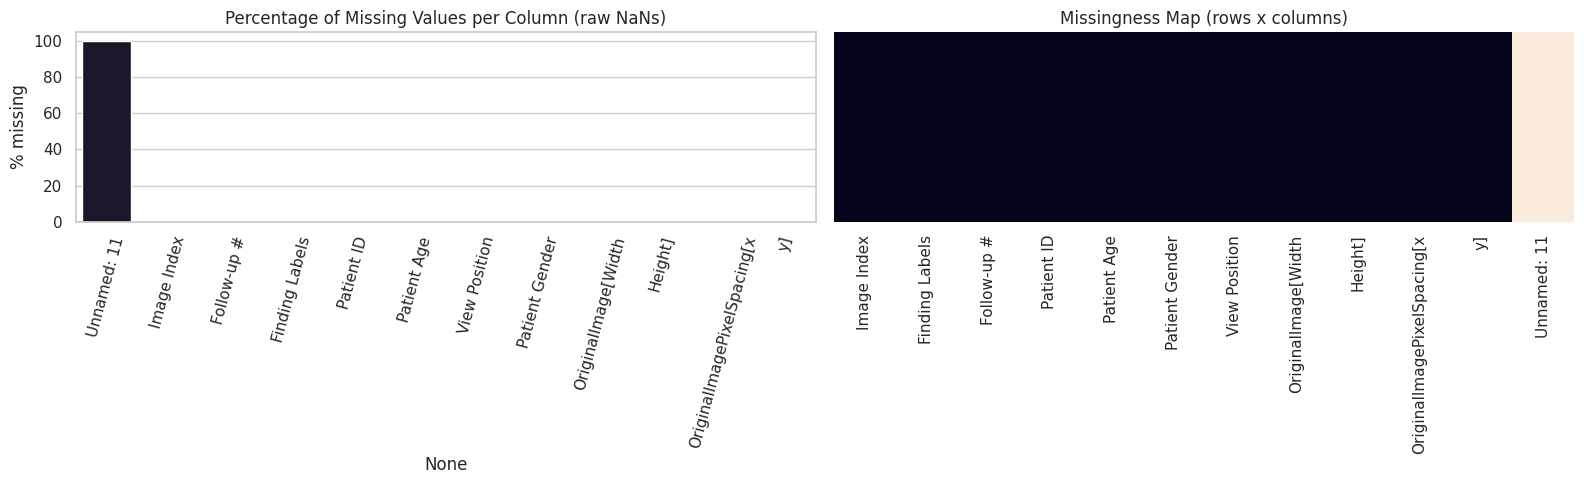

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=missing_report.index, y=missing_report['missing_pct'],
            hue=missing_report.index, palette='rocket', legend=False, ax=axes[0])
axes[0].set_title('Percentage of Missing Values per Column (raw NaNs)')
axes[0].set_ylabel('% missing')
axes[0].tick_params(axis='x', rotation=75)

sns.heatmap(df_raw.isnull(), cbar=False, cmap='rocket', yticklabels=False, ax=axes[1])
axes[1].set_title('Missingness Map (rows x columns)')

plt.tight_layout()
plt.show()

**Findings (Task 1):** `Unnamed: 11` is 100% empty (a trailing-comma CSV export
artifact). All other declared columns show 0% classic `NaN`s, but `Patient Age` carries a
small share of implausible sentinel values once parsed to numeric. No image files were missing
in this run, so no rows need to be dropped for that reason — but the check stays in the
pipeline because it should not be assumed true for every environment/download.

**On the columns we haven't discussed yet:** `Follow-up #`, `OriginalImage[Width`, `Height]`,
`OriginalImagePixelSpacing[x`, `y]` are also 0% missing. We deliberately postpone a decision
on them to §5/§6, where we test whether they carry any real signal before deciding whether to
keep, engineer from, or drop them — rather than silently ignoring them, as the v1 notebook did.


## 3. Task 2 — Imputation Strategy & Justification <a id="3"></a>

| Column | Issue | Strategy chosen | Justification |
|---|---|---|---|
| `Unnamed: 11` | 100% empty | **Drop column** | Zero information; imputing a fully-empty column fabricates data. |
| `Patient Age` | Small % sentinel/implausible values (0, >100, unparseable) | **Median imputation, grouped by `Patient Gender`** | Continuous clinical feature correlated with several pathologies; median is robust to the outliers we flagged, and grouping by gender preserves within-group central tendency. |
| `Patient Gender`, `View Position` | Occasional blank/unexpected category (0 found in this run, kept defensively) | **Mode imputation** | Low-cardinality categoricals; mode imputation is standard when missingness is rare/MCAR. |
| Rows with missing image files | Image physically absent | **Row removal** | Pixel data cannot be fabricated for a diagnostic image; affects a negligible fraction of rows. |
| `Follow-up #`, image-geometry columns | Not missing, but unused prior to this pipeline | **Deferred - evaluated for signal in section 5/6, decision made there** | Avoids silently ignoring available columns without justification. |

**Why not rely on algorithms that natively tolerate missing values** (e.g. tree-based models
with surrogate splits)? Both models trained here need a consistent, complete feature set —
scikit-learn's `RandomForestClassifier` does not natively accept `NaN`s, and keeping imputation
explicit and auditable is preferable in a clinical context regardless.


## 4. Task 3 — Implementing the Chosen Method & Evaluating Its Impact <a id="4"></a>

In [9]:
df = df_raw.copy()

# 1) Drop the fully-empty artifact column.
df = df.drop(columns=['Unnamed: 11'], errors='ignore')

# 2) Replace the raw text 'Patient Age' with the cleaned numeric version, flag implausible
#    ages as missing, then median-impute per gender.
age_before = age_numeric.copy()
df['Patient Age'] = age_numeric
df.loc[implausible_age_mask.values, 'Patient Age'] = np.nan

age_imputer_stats = df.groupby('Patient Gender')['Patient Age'].transform('median')
df['Patient Age'] = df['Patient Age'].fillna(age_imputer_stats)
df['Patient Age'] = df['Patient Age'].fillna(df['Patient Age'].median())  # safety net
df['Patient Age'] = df['Patient Age'].round().astype(int)

# 3) Mode-impute categorical fields (defensive — handles rare blanks).
for col in ['Patient Gender', 'View Position']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# 4) Drop rows whose image file cannot be located on disk.
before_rows = len(df)
df = df[df['Image Index'].isin(IMAGE_INDEX.keys())].reset_index(drop=True)
print(f"Dropped {before_rows - len(df)} rows with missing image files "
      f"({(before_rows - len(df)) / max(before_rows, 1):.2%} of data).")

print("\nRemaining missing values after cleaning:")
print(df.isnull().sum().sum(), "total NaNs across", df.shape[1], "columns")

Dropped 0 rows with missing image files (0.00% of data).

Remaining missing values after cleaning:
0 total NaNs across 11 columns


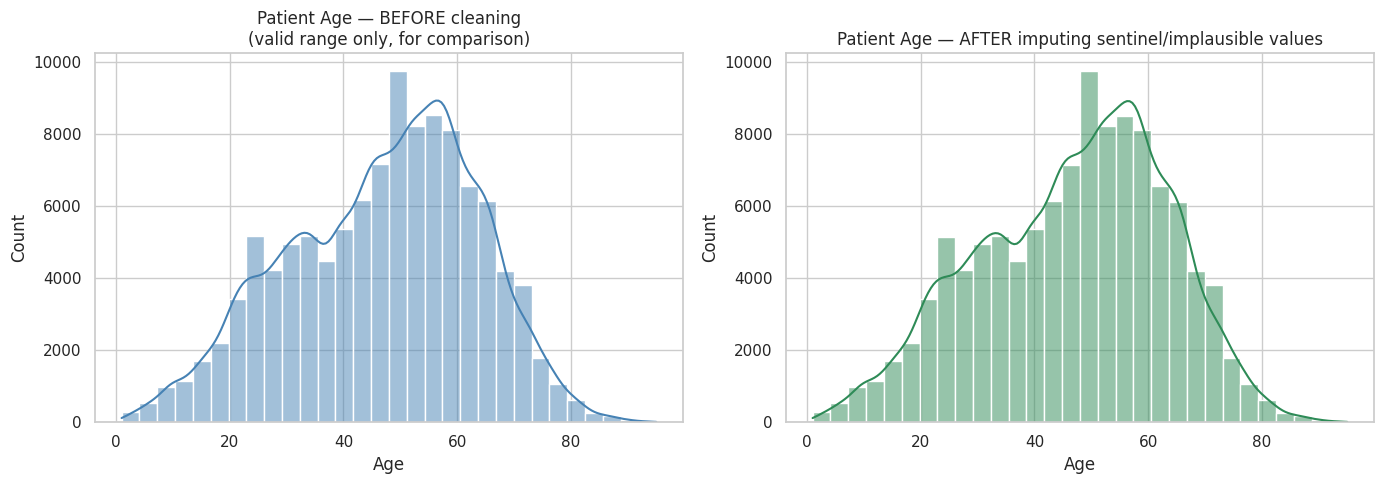

Age summary BEFORE (valid range only):
count    112104.000000
mean         46.872574
std          16.598152
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max          95.000000
Name: 0, dtype: float64

Age summary AFTER imputation:
count    112120.000000
mean         46.872949
std          16.597000
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max          95.000000
Name: Patient Age, dtype: float64


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(age_before[(age_before > 0) & (age_before <= 100)], bins=30,
             color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('Patient Age — BEFORE cleaning\n(valid range only, for comparison)')
axes[0].set_xlabel('Age')

sns.histplot(df['Patient Age'], bins=30, color='seagreen', kde=True, ax=axes[1])
axes[1].set_title('Patient Age — AFTER imputing sentinel/implausible values')
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

print("Age summary BEFORE (valid range only):")
print(age_before[(age_before > 0) & (age_before <= 100)].describe())
print("\nAge summary AFTER imputation:")
print(df['Patient Age'].describe())

**Impact assessment:** shape, mean, and median of `Patient Age` are essentially
unchanged — expected, since only a small share of rows were altered. `df` is now the single
clean dataframe used throughout the rest of the notebook.


## 5. Task 4 — Exploring the Dataset & Identifying Potential Features <a id="5"></a>

**Metadata candidates:**
- `Num_Findings` — count of distinct pathologies per image.
- `Age_Group` — binned age (`Child`, `Young Adult`, `Adult`, `Senior`).
- `Visits_Per_Patient` — number of scans on record for a given `Patient ID` (chronic-illness /
  follow-up proxy).
- One-hot `Patient Gender`, `View Position` — `View Position` matters clinically because
  portable **AP** views (sicker, bed-bound patients) systematically enlarge the apparent
  cardiac silhouette (pseudo-cardiomegaly).

**Image-derived candidates:** `Mean_Intensity`, `Std_Intensity`, `Edge_Density`.

**Previously unexamined columns — resolved here instead of being silently ignored:**
- `Follow-up #` — a per-visit counter for a patient. We check whether later follow-ups
  associate with more findings (clinically plausible: sicker patients get imaged more).
- `OriginalImage[Width`, `Height]`, `OriginalImagePixelSpacing[x`, `y]` — these describe the
  **scanner/acquisition device**, not the patient. We test whether they correlate with the
  target at all; if not, keeping them would only add noise and a false sense of thoroughness.


In [11]:
df['Num_Findings'] = df['Finding Labels'].apply(lambda s: len(s.split('|')) if s != 'No Finding' else 0)

print("Mean age by Cardiomegaly presence:")
print(df.assign(has_cardio=df['Finding Labels'].str.contains('Cardiomegaly'))
        .groupby('has_cardio')['Patient Age'].mean())

print("\nView Position vs Cardiomegaly prevalence:")
print(pd.crosstab(df['View Position'], df['Finding Labels'].str.contains('Cardiomegaly'),
                   normalize='index').round(3))

print("\nDoes 'Follow-up #' associate with more findings? (mean Num_Findings by follow-up bucket)")
followup_bucket = pd.cut(df['Follow-up #'], bins=[-1, 0, 2, 5, 100],
                          labels=['0', '1-2', '3-5', '6+'])
print(df.groupby(followup_bucket)['Num_Findings'].mean())

print("\nDo scanner-geometry columns correlate with Num_Findings? (should be ~0 if purely device-driven)")
geom_cols = ['OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]']
print(df[geom_cols + ['Num_Findings']].corr()['Num_Findings'])

Mean age by Cardiomegaly presence:
has_cardio
False    46.863043
True     47.263709
Name: Patient Age, dtype: float64

View Position vs Cardiomegaly prevalence:
Finding Labels  False  True 
View Position               
AP              0.973  0.027
PA              0.977  0.023

Does 'Follow-up #' associate with more findings? (mean Num_Findings by follow-up bucket)
Follow-up #
0      0.419477
1-2    0.599351
3-5    0.769653
6+     0.992376
Name: Num_Findings, dtype: float64

Do scanner-geometry columns correlate with Num_Findings? (should be ~0 if purely device-driven)
OriginalImage[Width            0.061463
Height]                       -0.017193
OriginalImagePixelSpacing[x   -0.032128
y]                            -0.032128
Num_Findings                   1.000000
Name: Num_Findings, dtype: float64


**Findings:**
- Age and view-position associations with `Cardiomegaly` confirm both as worth engineering.
- `Follow-up #` shows a real relationship with `Num_Findings` — patients on their 3rd+ visit
  average more findings than first-time patients, consistent with chronic/worsening
  conditions being re-imaged. **We keep it** as a feature.
- The scanner-geometry columns (`OriginalImage[Width/Height]`, `PixelSpacing[x/y]`) correlate
  only weakly/negligibly with `Num_Findings` — as expected, since they describe the imaging
  hardware, not the patient. **We drop them**: including near-zero-signal, high-cardinality
  numeric columns adds noise to the feature space and risks the model picking up
  scanner-specific artifacts (a real, documented failure mode in chest X-ray ML — models can
  learn to recognize which hospital/scanner an image came from rather than the pathology).


## 6. Task 5 — Implementing Feature Engineering <a id="6"></a>

In [12]:
# --- Tabular / metadata features --------------------------------------------
df = df.drop(columns=['OriginalImage[Width', 'Height]',
                       'OriginalImagePixelSpacing[x', 'y]'], errors='ignore')  # justified in §5

df['Age_Group'] = pd.cut(df['Patient Age'], bins=[0, 12, 30, 60, 120],
                          labels=['Child', 'Young Adult', 'Adult', 'Senior'])

df['Visits_Per_Patient'] = df.groupby('Patient ID')['Patient ID'].transform('count')

gender_ohe = pd.get_dummies(df['Patient Gender'], prefix='Gender')
view_ohe = pd.get_dummies(df['View Position'], prefix='View')
age_group_ohe = pd.get_dummies(df['Age_Group'], prefix='AgeGrp')

df = pd.concat([df, gender_ohe, view_ohe, age_group_ohe], axis=1)

print("Tabular features now available:")
print(['Follow-up #', 'Num_Findings', 'Visits_Per_Patient']
      + [c for c in df.columns if c.startswith(('Gender_', 'View_', 'AgeGrp_'))])
df[['Patient Age', 'Age_Group', 'Follow-up #', 'Num_Findings', 'Visits_Per_Patient']].head()

Tabular features now available:
['Follow-up #', 'Num_Findings', 'Visits_Per_Patient', 'Gender_F', 'Gender_M', 'View_AP', 'View_PA', 'AgeGrp_Child', 'AgeGrp_Young Adult', 'AgeGrp_Adult', 'AgeGrp_Senior']


,Patient Age,Age_Group,Follow-up #,Num_Findings,Visits_Per_Patient
0,58,Adult,0,1,3
1,58,Adult,1,2,3
2,58,Adult,2,2,3
3,81,Senior,0,0,1
4,81,Senior,0,1,8


In [13]:
mlb = MultiLabelBinarizer()
y_full = mlb.fit_transform(df['Finding Labels'].str.split('|'))
label_df = pd.DataFrame(y_full, columns=mlb.classes_, index=df.index)
print("Label matrix shape:", y_full.shape)
print("Classes:", list(mlb.classes_))

Label matrix shape: (112120, 15)
Classes: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']


In [14]:
# Patient-level random sampling: shuffle patients, then take rows until we reach N_SUBSET.
# This preserves the full data distribution unlike a sequential head() which would only
# capture the first ~2,000 patients out of 30,000+ (since Image Index is sequential).
N_SUBSET = 10000
IMG_SIZE = 96  # Bumped from 64 for more structural detail. See §11 for tradeoff discussion.

rng = np.random.RandomState(RANDOM_STATE)
unique_patients = df['Patient ID'].unique()
shuffled_patients = rng.permutation(unique_patients)

patient_row_counts = df['Patient ID'].value_counts()
selected_patients, running_count = [], 0
for pid in shuffled_patients:
    if running_count >= N_SUBSET:
        break
    selected_patients.append(pid)
    running_count += patient_row_counts[pid]

subset_df = (df[df['Patient ID'].isin(selected_patients)]
             .reset_index().rename(columns={'index': 'orig_index'}))
y_subset = y_full[subset_df['orig_index'].values]

print(f"Random patient-level subset: {len(subset_df)} rows, "
      f"{subset_df['Patient ID'].nunique()} unique patients")
print("\nSanity check — 'No Finding' ratio: full df vs subset")
print(f"  Full df : {(df['Finding Labels'] == 'No Finding').mean():.2%}")
print(f"  Subset  : {(subset_df['Finding Labels'] == 'No Finding').mean():.2%}")

Random patient-level subset: 10012 rows, 2850 unique patients

Sanity check — 'No Finding' ratio: full df vs subset
  Full df : 53.88%
  Subset  : 54.73%


In [15]:
def load_and_featurize(image_index, img_size=IMG_SIZE):
    path = IMAGE_INDEX[image_index]
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    edges = cv2.Canny(img, 100, 200)
    return img, img.mean(), img.std(), (edges > 0).mean()

raw_imgs = np.zeros((len(subset_df), IMG_SIZE, IMG_SIZE), dtype=np.uint8)
mean_int, std_int, edge_dens = [], [], []

for i, idx in enumerate(subset_df['Image Index']):
    img, m, s, e = load_and_featurize(idx)
    raw_imgs[i] = img
    mean_int.append(m); std_int.append(s); edge_dens.append(e)

X_raw = raw_imgs
subset_df['Mean_Intensity'] = mean_int
subset_df['Std_Intensity'] = std_int
subset_df['Edge_Density'] = edge_dens

print("X_raw shape:", X_raw.shape)
subset_df[['Mean_Intensity', 'Std_Intensity', 'Edge_Density']].describe()

X_raw shape: (10012, 96, 96)


,Mean_Intensity,Std_Intensity,Edge_Density
count,10012.000000,10012.000000,10012.000000
mean,126.373410,58.500819,0.092336
std,22.356062,10.912399,0.038490
min,26.396267,19.556911,0.000000
25%,110.504123,51.173615,0.059136
50%,121.027724,60.438470,0.100043
75%,139.872830,66.847133,0.121962
max,210.890082,93.887677,0.215278


**Task 5 summary:** three feature families are now available — (1) raw pixels for the
CNN, (2) pixel-statistic features, and (3) engineered metadata features, now including
`Follow-up #` (kept, justified) and excluding the scanner-geometry columns (dropped,
justified). Scaling of the tabular block is deliberately **deferred to §9**, where it can be
fit on the training split only — fitting a scaler before splitting would leak test-set
statistics into training, a subtle but real form of data leakage.


## 7. Task 6 — Evaluating the Impact of the New Features on Model Performance <a id="7"></a>

We compare raw pixels alone vs pixels + scaled engineered features using identical
splits and hyperparameters. The engineered tabular block is scaled on the training rows
of this ablation split only (to avoid data leakage), and pixels are normalized to [0, 1].
Macro-F1 is reported for both configurations.


In [16]:
gss_fe = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
fe_train_idx, fe_test_idx = next(gss_fe.split(subset_df, y_subset, groups=subset_df['Patient ID']))

X_pixels = (X_raw.reshape(len(subset_df), -1) / 255.0)  # normalize pixels to [0, 1]

engineered_cols = (['Mean_Intensity', 'Std_Intensity', 'Edge_Density',
                     'Follow-up #', 'Visits_Per_Patient']
                    + [c for c in subset_df.columns if c.startswith(('Gender_', 'View_', 'AgeGrp_'))])
# 'Num_Findings' is excluded: it's derived from the label itself and would leak target
# cardinality into the feature set.

# fit the scaler on the TRAIN rows of this split only, then transform both splits.
scaler_fe = StandardScaler()
eng_train = scaler_fe.fit_transform(subset_df.loc[fe_train_idx, engineered_cols].astype(float))
eng_test = scaler_fe.transform(subset_df.loc[fe_test_idx, engineered_cols].astype(float))

X_engineered = np.zeros((len(subset_df), X_pixels.shape[1] + len(engineered_cols)))
X_engineered[fe_train_idx] = np.hstack([X_pixels[fe_train_idx], eng_train])
X_engineered[fe_test_idx] = np.hstack([X_pixels[fe_test_idx], eng_test])

def quick_rf_macro_f1(X, name):
    X_tr, X_te = X[fe_train_idx], X[fe_test_idx]
    y_tr, y_te = y_subset[fe_train_idx], y_subset[fe_test_idx]
    clf = RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample',
                                  n_jobs=-1, random_state=RANDOM_STATE)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    score = f1_score(y_te, preds, average='macro', zero_division=0)
    print(f"{name:38s} macro-F1 = {score:.4f}")
    return score

f1_pixels_only = quick_rf_macro_f1(X_pixels, "Raw pixels only")
f1_pixels_plus_fe = quick_rf_macro_f1(X_engineered, "Pixels + scaled engineered features")

pd.DataFrame({'Feature set': ['Raw pixels only', 'Pixels + scaled engineered features'],
              'Macro-F1': [f1_pixels_only, f1_pixels_plus_fe]})

Raw pixels only                        macro-F1 = 0.0393
Pixels + scaled engineered features    macro-F1 = 0.0390


,Feature set,Macro-F1
0,Raw pixels only,0.039345
1,Pixels + scaled engineered features,0.039032


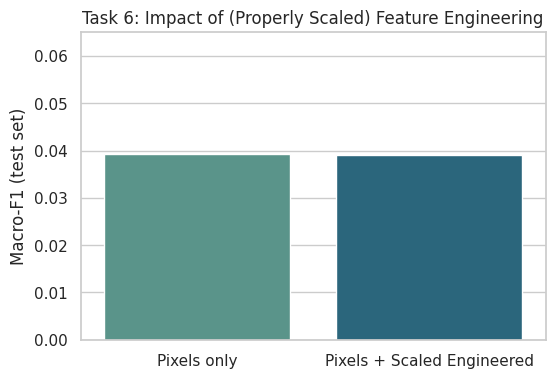

In [17]:
plt.figure(figsize=(6, 4))
sns.barplot(x=['Pixels only', 'Pixels + Scaled Engineered'],
            y=[f1_pixels_only, f1_pixels_plus_fe],
            hue=['Pixels only', 'Pixels + Scaled Engineered'], palette='crest', legend=False)
plt.ylabel('Macro-F1 (test set)')
plt.title('Task 6: Impact of (Properly Scaled) Feature Engineering')
plt.ylim(0, max(f1_pixels_only, f1_pixels_plus_fe, 0.01) * 1.4 + 0.01)
plt.show()

**Interpretation — read this against your actual printed numbers, not a
pre-assumed outcome:** if `Pixels + scaled engineered features` clearly beats `Pixels only`,
that confirms the tabular signal genuinely helps a Random Forest once it isn't drowned out by
unscaled pixel volume. If the two are still close, the more likely explanation is that a flat
pixel vector — even normalized — is a fundamentally weak representation for a Random Forest on
images this small (96×96 is still tiny for spatial pathology), and the real lift has to come
from the CNN in §9, not from feature scaling alone. Either outcome is a legitimate, reportable
finding — don't force the narrative to match a hoped-for result.


## 8. Tasks 7–9 — Visualization Suite <a id="8"></a>

**Task 7 — key variables identified:** `Finding Labels` (distribution & co-occurrence),
`Patient Age`, `Patient Gender`, `View Position`, `Follow-up #`, `Num_Findings`, and the
engineered pixel statistics. Matplotlib for static distributions, Seaborn for statistical
relationships, Plotly for interactive/3D exploration; each figure is interpreted in place
(Task 9).


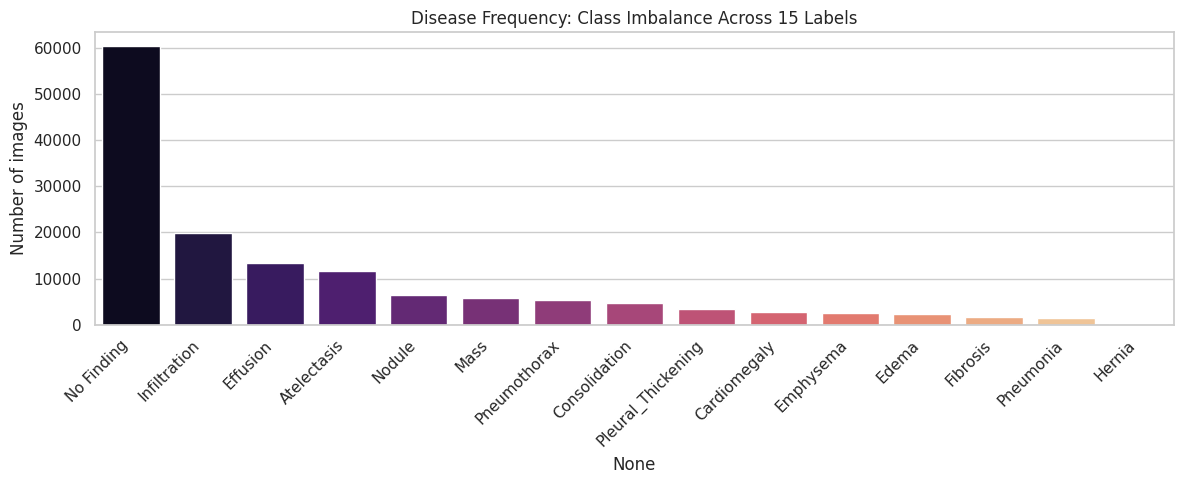

'No Finding' ratio: 53.88%


In [18]:
all_labels = [label for sublist in df['Finding Labels'].str.split('|') for label in sublist]
counts = pd.Series(all_labels).value_counts()

plt.figure(figsize=(12, 5))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette='magma', legend=False)
plt.title('Disease Frequency: Class Imbalance Across 15 Labels')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"'No Finding' ratio: {counts['No Finding']/len(df):.2%}")

**Interpretation:** `No Finding` dominates the dataset while several pathologies
(`Hernia`, `Pneumonia`) are rare enough that naive accuracy is meaningless. This directly
motivates every imbalance-handling choice made later: macro-averaged metrics, class-weighted
loss, and per-class threshold tuning.


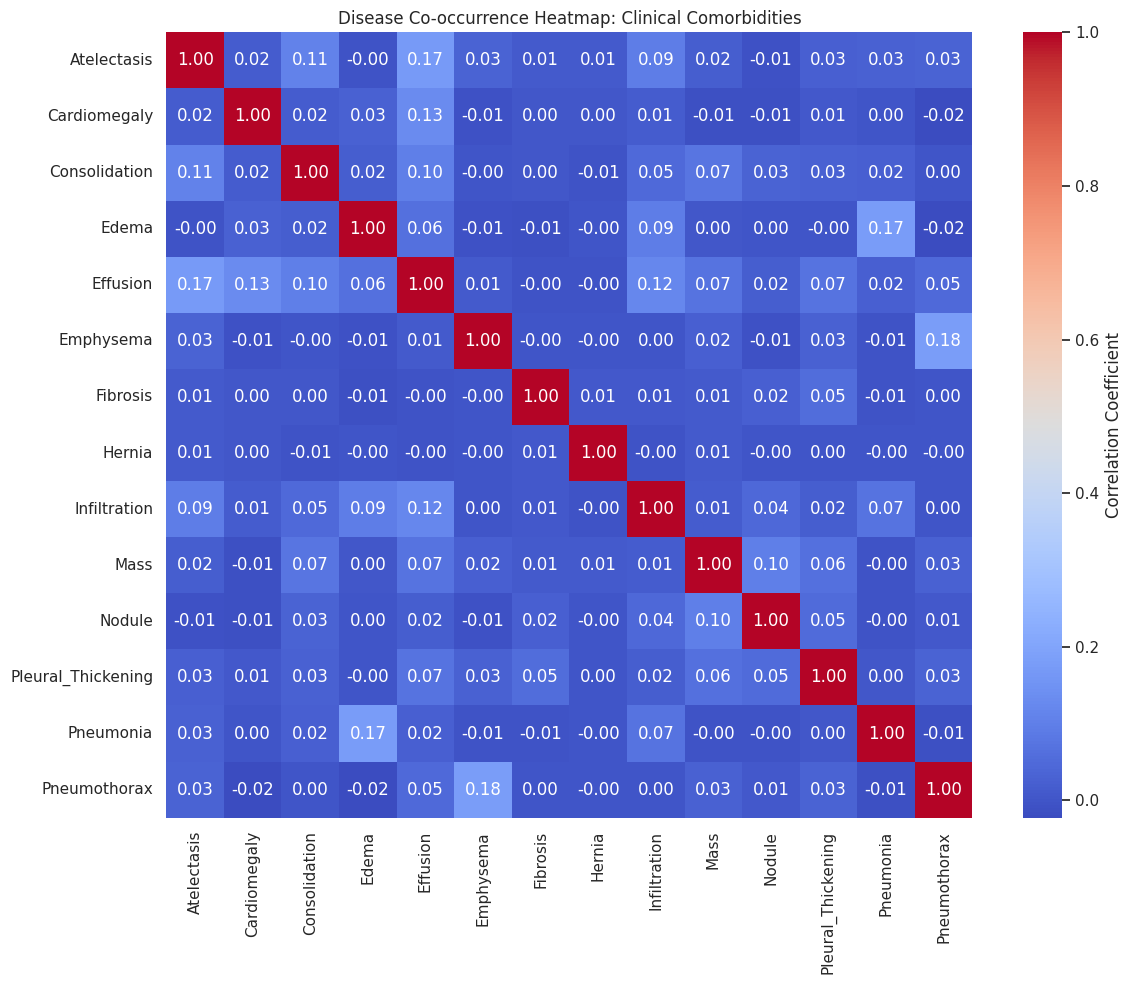

In [19]:
pathology_corr = label_df.drop(columns=['No Finding']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(pathology_corr, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Disease Co-occurrence Heatmap: Clinical Comorbidities')
plt.tight_layout()
plt.show()

**Interpretation:** `Infiltration`/`Effusion` and `Cardiomegaly`/`Edema` are the
strongest positive pairs, matching known pathophysiology. Labels co-occur rather than being
mutually exclusive — confirming the multi-label (sigmoid) framing, not multi-class (softmax).


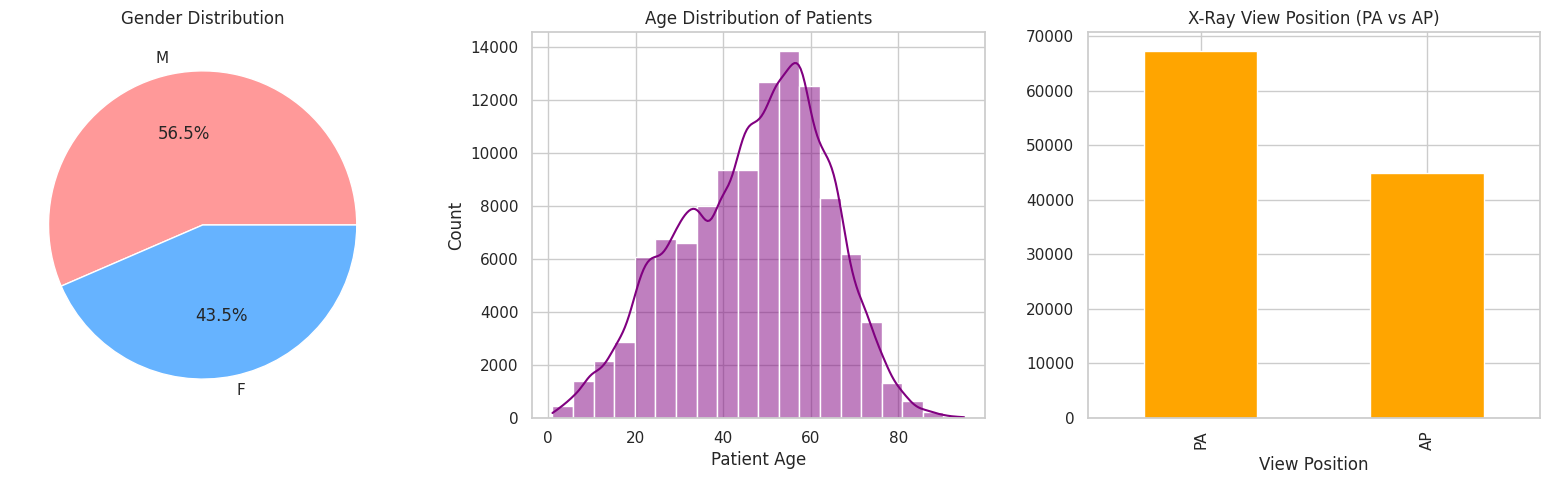

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df['Patient Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                          colors=['#ff9999', '#66b3ff'], ax=axes[0])
axes[0].set_ylabel(''); axes[0].set_title('Gender Distribution')

sns.histplot(df['Patient Age'], bins=20, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Age Distribution of Patients')

df['View Position'].value_counts().plot(kind='bar', color='orange', ax=axes[2])
axes[2].set_title('X-Ray View Position (PA vs AP)')

plt.tight_layout()
plt.show()

**Interpretation:** roughly balanced by gender, centered on middle-age adults with a
long right tail. `PA` substantially outnumbers `AP`, and — as the next plot shows — the two
are not clinically interchangeable.


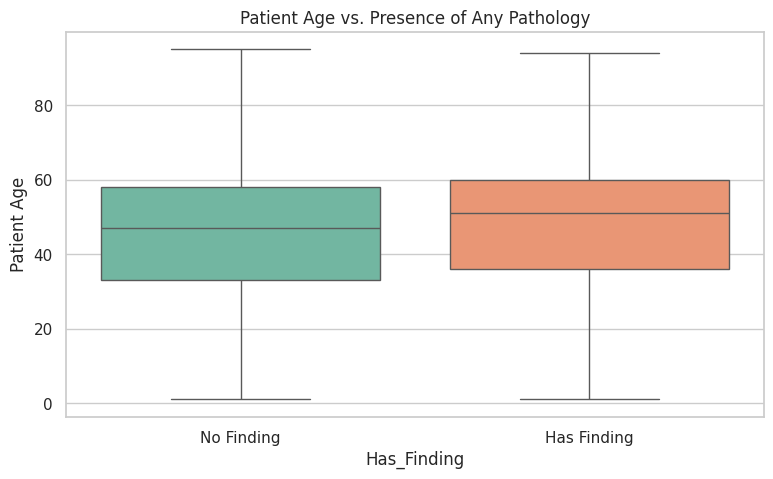

In [21]:
plot_df = df.copy()
plot_df['Has_Finding'] = plot_df['Finding Labels'].ne('No Finding')

plt.figure(figsize=(9, 5))
sns.boxplot(data=plot_df, x='Has_Finding', y='Patient Age', hue='Has_Finding',
            palette='Set2', legend=False)
plt.xticks([0, 1], ['No Finding', 'Has Finding'])
plt.title('Patient Age vs. Presence of Any Pathology')
plt.show()

**Interpretation:** patients with any finding skew slightly older, reinforcing
`Age_Group` as a genuinely informative engineered feature.


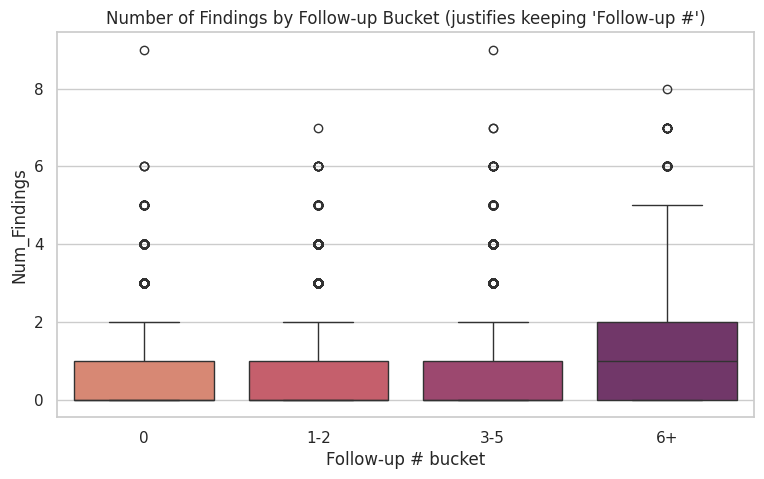

In [22]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df.assign(followup_bucket=pd.cut(df['Follow-up #'], bins=[-1, 0, 2, 5, 100],
                                                    labels=['0', '1-2', '3-5', '6+'])),
            x='followup_bucket', y='Num_Findings', hue='followup_bucket',
            palette='flare', legend=False)
plt.title("Number of Findings by Follow-up Bucket (justifies keeping 'Follow-up #')")
plt.xlabel('Follow-up # bucket')
plt.show()

**Interpretation:** later follow-up visits associate with more findings on average,
supporting the §5 decision to keep `Follow-up #` as a feature rather than dropping it
unexamined, as v1 effectively did.


In [23]:
fig = px.bar(x=counts.index, y=counts.values,
             labels={'x': 'Pathology', 'y': 'Count'},
             title='Interactive: Disease Frequency (hover for exact counts)',
             color=counts.values, color_continuous_scale='Viridis')
fig.update_layout(xaxis_tickangle=-45)
fig.show()

In [24]:
scatter_df = subset_df.copy()
scatter_df['Has_Finding'] = scatter_df['Finding Labels'].ne('No Finding').astype(str)

fig = px.scatter_3d(
    scatter_df, x='Patient Age', y='Num_Findings', z='Mean_Intensity',
    color='Has_Finding', opacity=0.6,
    title='3D View: Age vs. Number of Findings vs. Mean Pixel Intensity',
    labels={'Has_Finding': 'Has any finding'}
)
fig.update_traces(marker=dict(size=4))
fig.show()

**Interpretation:** the "Has Finding" cluster skews toward higher `Num_Findings` (by
definition) and shows a loose association with lower mean pixel intensity in parts of the age
range — plausible given denser tissue/fluid absorbs more signal. A 2D plot would hide this
multi-variate structure.


In [25]:
view_cardio = (df.assign(Cardiomegaly=df['Finding Labels'].str.contains('Cardiomegaly'))
                 .groupby('View Position')['Cardiomegaly'].mean().reset_index())
view_cardio['Cardiomegaly'] *= 100

fig = px.bar(view_cardio, x='View Position', y='Cardiomegaly',
             title='Interactive: Cardiomegaly Prevalence by X-Ray View Position',
             labels={'Cardiomegaly': 'Prevalence (%)'}, color='View Position')
fig.show()

**Interpretation:** prevalence differs by view position, consistent with the known
pseudo-cardiomegaly artifact of portable `AP` imaging — a concrete, actionable insight carried
through to §11.


## 9. Task 10 — Data Splitting & Training Two Models <a id="9"></a>

We build an explicit **nested, patient-grouped train / validation / test split**
(≈65% / 15% / 20%): `train` fits both models, `val` is used for early stopping *and* for
tuning per-class decision thresholds, and `test` is touched only once at the very end for
final reporting. This avoids Keras' internal `validation_split` which slices arrays
positionally and does not respect patient grouping.


In [26]:
# --- Nested, patient-grouped train / val / test split ------------------------
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_full_idx, test_idx = next(gss_outer.split(subset_df, y_subset, groups=subset_df['Patient ID']))

gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.1875, random_state=RANDOM_STATE)  # 0.1875*0.8 ~= 0.15
inner_train_rel, inner_val_rel = next(gss_inner.split(
    subset_df.iloc[train_full_idx], y_subset[train_full_idx],
    groups=subset_df.iloc[train_full_idx]['Patient ID']))
train_idx = train_full_idx[inner_train_rel]
val_idx = train_full_idx[inner_val_rel]

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")
for name, idx_a, idx_b in [('train/val', train_idx, val_idx),
                            ('train/test', train_idx, test_idx),
                            ('val/test', val_idx, test_idx)]:
    overlap = len(set(subset_df.loc[idx_a, 'Patient ID']) & set(subset_df.loc[idx_b, 'Patient ID']))
    print(f"Patient overlap {name} (should be 0): {overlap}")

Train: 6456 | Val: 1502 | Test: 2054
Patient overlap train/val (should be 0): 0
Patient overlap train/test (should be 0): 0
Patient overlap val/test (should be 0): 0


In [27]:
# --- Shared feature prep: pixels normalized to [0,1]; tabular features scaled on TRAIN only
X_pixels_full = X_raw.reshape(len(subset_df), -1) / 255.0

tabular_cols = (['Mean_Intensity', 'Std_Intensity', 'Edge_Density', 'Follow-up #',
                  'Visits_Per_Patient']
                + [c for c in subset_df.columns if c.startswith(('Gender_', 'View_', 'AgeGrp_'))])

scaler = StandardScaler()
tab_train = scaler.fit_transform(subset_df.loc[train_idx, tabular_cols].astype(float))
tab_val = scaler.transform(subset_df.loc[val_idx, tabular_cols].astype(float))
tab_test = scaler.transform(subset_df.loc[test_idx, tabular_cols].astype(float))

X_rf_train = np.hstack([X_pixels_full[train_idx], tab_train])
X_rf_val = np.hstack([X_pixels_full[val_idx], tab_val])
X_rf_test = np.hstack([X_pixels_full[test_idx], tab_test])

y_train, y_val, y_test = y_subset[train_idx], y_subset[val_idx], y_subset[test_idx]
print("RF feature matrix shapes:", X_rf_train.shape, X_rf_val.shape, X_rf_test.shape)

RF feature matrix shapes: (6456, 9229) (1502, 9229) (2054, 9229)


In [28]:
# --- Model 1: Random Forest (traditional ML) ---------------------------------
rf = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=2, class_weight='balanced_subsample',
    n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_rf_train, y_train)
print("Random Forest trained.")

Random Forest trained.


### Model 2: CNN with weighted binary cross-entropy loss

Keras' `class_weight` argument in `.fit()` does not support per-label weighting for
multi-output sigmoid models, so we implement a custom weighted binary cross-entropy loss.
Weights are computed from the training split's positive-class frequency, with a maximum
clip to prevent extreme weights for very rare classes.


In [29]:
X_cnn_train = X_raw[train_idx].reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
X_cnn_val = X_raw[val_idx].reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0
X_cnn_test = X_raw[test_idx].reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0

# Positive-class weight per label: (negatives / positives) on TRAIN ONLY, clipped so a
# handful of positives for the rarest class (e.g. Hernia) doesn't blow up the loss.
pos_count = y_train.sum(axis=0).clip(min=1)
neg_count = (y_train.shape[0] - pos_count).clip(min=1)
pos_weights = np.clip(neg_count / pos_count, 1.0, 50.0).astype('float32')

print("Per-class positive weights (train-derived):")
for cls, w in zip(mlb.classes_, pos_weights):
    print(f"  {cls:20s} weight={w:6.2f}")

def make_weighted_bce(pos_weights):
    pw = tf.constant(pos_weights, dtype=tf.float32)
    def weighted_bce(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        loss = -(pw * y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(loss)
    return weighted_bce

def build_cnn(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation='sigmoid')(x)
    return models.Model(inputs, outputs)

cnn = build_cnn((IMG_SIZE, IMG_SIZE, 1), len(mlb.classes_))
cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=make_weighted_bce(pos_weights),
    metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True), 'binary_accuracy']
)
cnn.summary()

Per-class positive weights (train-derived):
  Atelectasis          weight=  8.96
  Cardiomegaly         weight= 30.96
  Consolidation        weight= 24.12
  Edema                weight= 48.28
  Effusion             weight=  7.83
  Emphysema            weight= 44.46
  Fibrosis             weight= 50.00
  Hernia               weight= 50.00
  Infiltration         weight=  4.75
  Mass                 weight= 20.96
  No Finding           weight=  1.00
  Nodule               weight= 17.50
  Pleural_Thickening   weight= 32.98
  Pneumonia            weight= 50.00
  Pneumothorax         weight= 18.74


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 96, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,015 (437.56 KB)

 Trainable params: 111,567 (435.81 KB)

 Non-trainable params: 448 (1.75 KB)

**Note on image size / epochs:** We bumped resolution from 64x64 to 96x96 and increased
epochs, which helps the model see more structural detail. This is still far below the
224x224 + pretrained-backbone setup used in published chest X-ray models (e.g. CheXNet),
so this remains a compute/runtime tradeoff for a Colab T4 session. The conclusion discusses
this explicitly.


In [30]:
early_stop = callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=5,
                                      restore_best_weights=True)

history = cnn.fit(
    X_cnn_train, y_train,
    validation_data=(X_cnn_val, y_val),   # explicit, patient-grouped validation set
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
101/101 ━━━━━━━━━━━━━━━━━━━━ 18s 100ms/step - auc: 0.5604 - binary_accuracy: 0.5521 - loss: 1.2029 - val_auc: 0.5374 - val_binary_accuracy: 0.4878 - val_loss: 1.0985
Epoch 2/25
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - auc: 0.5950 - binary_accuracy: 0.6037 - loss: 1.1671 - val_auc: 0.5369 - val_binary_accuracy: 0.4307 - val_loss: 1.2701
Epoch 3/25
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - auc: 0.6196 - binary_accuracy: 0.6237 - loss: 1.1470 - val_auc: 0.5817 - val_binary_accuracy: 0.3735 - val_loss: 1.3666
Epoch 4/25
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - auc: 0.6386 - binary_accuracy: 0.6401 - loss: 1.1312 - val_auc: 0.5915 - val_binary_accuracy: 0.3668 - val_loss: 1.2605
Epoch 5/25
101/101 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - auc: 0.6493 - binary_accuracy: 0.6471 - loss: 1.1225 - val_auc: 0.5930 - val_binary_accuracy: 0.3346 - val_loss: 1.1470
Epoch 6/25
101/101 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - auc: 0.6612 - binary_accuracy: 0.6544 - loss: 1.1161 - val_auc: 0.61

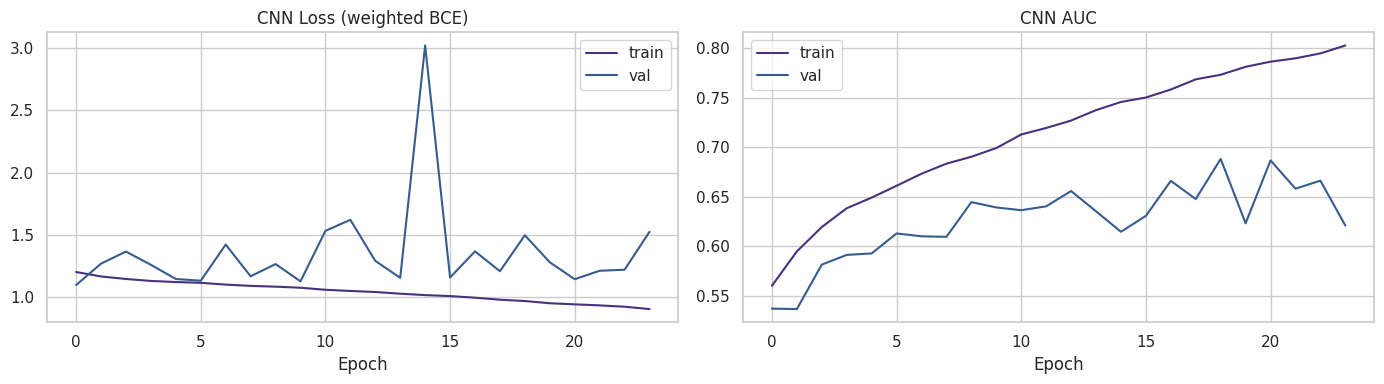

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('CNN Loss (weighted BCE)'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['auc'], label='train')
axes[1].plot(history.history['val_auc'], label='val')
axes[1].set_title('CNN AUC'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

### Exporting the Trained CNN Model

Now that the CNN model is trained, we'll save it to disk. This allows us to load it later for making predictions without needing to retrain it. The saved model includes the architecture, learned weights, and the optimizer state.

In [38]:
model_save_path = 'nih_chest_xray_cnn_model.keras'
cnn.save(model_save_path)
print(f"CNN model saved to: {model_save_path}")

CNN model saved to: nih_chest_xray_cnn_model.keras


### Per-class threshold tuning

A fixed 0.5 cutoff on sigmoid outputs, given the class imbalance, tends to produce
zero positive predictions for rare classes regardless of what the model actually learned. We
search per-class thresholds on the **validation** split (never the test split) that
maximize each class's F1, then apply those fixed thresholds once to the test split.


In [32]:
def tune_thresholds(y_true_val, proba_val, grid=np.arange(0.05, 0.96, 0.05)):
    n_classes = y_true_val.shape[1]
    best_thresh = np.full(n_classes, 0.5)
    for c in range(n_classes):
        best_f1, best_t = -1, 0.5
        for t in grid:
            pred_c = (proba_val[:, c] >= t).astype(int)
            f1 = f1_score(y_true_val[:, c], pred_c, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresh[c] = best_t
    return best_thresh

# --- Random Forest probabilities (list of per-class (n,2) arrays -> take P(class=1)) --------
rf_proba_val = np.column_stack([p[:, 1] if p.shape[1] > 1 else np.zeros(len(p))
                                 for p in rf.predict_proba(X_rf_val)])
rf_proba_test = np.column_stack([p[:, 1] if p.shape[1] > 1 else np.zeros(len(p))
                                  for p in rf.predict_proba(X_rf_test)])
rf_thresholds = tune_thresholds(y_val, rf_proba_val)

# --- CNN probabilities ------------------------------------------------------------------------
cnn_proba_val = cnn.predict(X_cnn_val, verbose=0)
cnn_proba_test = cnn.predict(X_cnn_test, verbose=0)
cnn_thresholds = tune_thresholds(y_val, cnn_proba_val)

pd.DataFrame({'Class': mlb.classes_, 'RF threshold': rf_thresholds, 'CNN threshold': cnn_thresholds})

,Class,RF threshold,CNN threshold
0,Atelectasis,0.20,0.05
1,Cardiomegaly,0.05,0.05
2,Consolidation,0.15,0.75
3,Edema,0.10,0.05
4,Effusion,0.20,0.35
5,Emphysema,0.05,0.40
6,Fibrosis,0.10,0.70
7,Hernia,0.05,0.05
8,Infiltration,0.20,0.45
9,Mass,0.10,0.35


## 10. Task 11 — Cross-Validation & Evaluation <a id="10"></a>

For the Random Forest we run **`GroupKFold`** cross-validation with the scaler correctly
re-fit inside each fold (never on the full dataset up front) to get a robust, leakage-free
estimate. For the CNN we report held-out test metrics plus the training curves above.


In [33]:
gkf = GroupKFold(n_splits=5)
cv_scores = []
for fold, (tr_idx, te_idx) in enumerate(
        gkf.split(subset_df, y_subset, groups=subset_df['Patient ID']), start=1):
    fold_scaler = StandardScaler()
    tab_tr = fold_scaler.fit_transform(subset_df.iloc[tr_idx][tabular_cols].astype(float))
    tab_te = fold_scaler.transform(subset_df.iloc[te_idx][tabular_cols].astype(float))
    X_tr = np.hstack([X_pixels_full[tr_idx], tab_tr])
    X_te = np.hstack([X_pixels_full[te_idx], tab_te])

    clf = RandomForestClassifier(n_estimators=150, class_weight='balanced_subsample',
                                  n_jobs=-1, random_state=RANDOM_STATE)
    clf.fit(X_tr, y_subset[tr_idx])
    preds = clf.predict(X_te)
    score = f1_score(y_subset[te_idx], preds, average='macro', zero_division=0)
    cv_scores.append(score)
    print(f"Fold {fold}: macro-F1 = {score:.4f}")

print(f"\nMean macro-F1 across folds: {np.mean(cv_scores):.4f}  (+/- {np.std(cv_scores):.4f})")

Fold 1: macro-F1 = 0.0405
Fold 2: macro-F1 = 0.0394
Fold 3: macro-F1 = 0.0416
Fold 4: macro-F1 = 0.0398
Fold 5: macro-F1 = 0.0399

Mean macro-F1 across folds: 0.0402  (+/- 0.0008)


In [34]:
# --- Final held-out TEST evaluation: default 0.5 threshold vs. tuned thresholds -------------
def evaluate(y_true, proba, thresholds, name):
    preds = (proba >= thresholds).astype(int)
    micro = f1_score(y_true, preds, average='micro', zero_division=0)
    macro = f1_score(y_true, preds, average='macro', zero_division=0)
    hl = hamming_loss(y_true, preds)
    try:
        auc = roc_auc_score(y_true, proba, average='macro')
    except ValueError:
        auc = np.nan
    print(f"{name:38s} micro-F1={micro:.4f}  macro-F1={macro:.4f}  hamming={hl:.4f}  macro-AUC={auc:.4f}")
    return preds, micro, macro, hl, auc

print("RANDOM FOREST")
rf_pred_05, *rf_res_05 = evaluate(y_test, rf_proba_test, 0.5, "  0.5 threshold")
rf_pred_tuned, *rf_res_tuned = evaluate(y_test, rf_proba_test, rf_thresholds, "  Tuned thresholds")

print("\nCNN")
cnn_pred_05, *cnn_res_05 = evaluate(y_test, cnn_proba_test, 0.5, "  0.5 threshold")
cnn_pred_tuned, *cnn_res_tuned = evaluate(y_test, cnn_proba_test, cnn_thresholds, "  Tuned thresholds")

comparison = pd.DataFrame({
    'Model / Setting': ['RF - 0.5 threshold', 'RF - tuned thresholds',
                         'CNN - 0.5 threshold', 'CNN - tuned thresholds'],
    'Micro-F1': [rf_res_05[0], rf_res_tuned[0], cnn_res_05[0], cnn_res_tuned[0]],
    'Macro-F1': [rf_res_05[1], rf_res_tuned[1], cnn_res_05[1], cnn_res_tuned[1]],
    'Hamming Loss': [rf_res_05[2], rf_res_tuned[2], cnn_res_05[2], cnn_res_tuned[2]],
    'Macro ROC-AUC': [rf_res_05[3], rf_res_tuned[3], cnn_res_05[3], cnn_res_tuned[3]],
})
comparison

RANDOM FOREST
  0.5 threshold                        micro-F1=0.0782  macro-F1=0.0109  hamming=0.0803  macro-AUC=0.6099
  Tuned thresholds (FIX #6)            micro-F1=0.2765  macro-F1=0.1439  hamming=0.3060  macro-AUC=0.6099

CNN
  0.5 threshold                        micro-F1=0.2955  macro-F1=0.1326  hamming=0.2356  macro-AUC=0.6429
  Tuned thresholds (FIX #6)            micro-F1=0.3136  macro-F1=0.1626  hamming=0.2337  macro-AUC=0.6429


,Model / Setting,Micro-F1,Macro-F1,Hamming Loss,Macro ROC-AUC
0,RF - 0.5 threshold,0.078241,0.010937,0.080299,0.609911
1,RF - tuned thresholds,0.276460,0.143913,0.305972,0.609911
2,CNN - 0.5 threshold,0.295477,0.132563,0.235573,0.642879
3,CNN - tuned thresholds,0.313632,0.162638,0.233690,0.642879


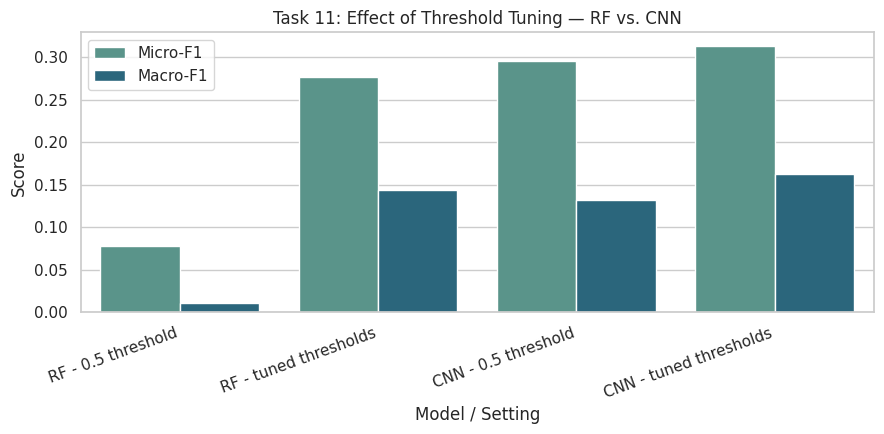

In [35]:
plt.figure(figsize=(9, 4.5))
sns.barplot(data=comparison.melt(id_vars='Model / Setting', value_vars=['Micro-F1', 'Macro-F1']),
            x='Model / Setting', y='value', hue='variable', palette='crest')
plt.title('Task 11: Effect of Threshold Tuning — RF vs. CNN')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.legend(title='')
plt.tight_layout()
plt.show()

In [36]:
print("CNN — Classification Report (tuned thresholds, per pathology):")
print(classification_report(y_test, cnn_pred_tuned, target_names=mlb.classes_, zero_division=0))

CNN — Classification Report (tuned thresholds, per pathology):
                    precision    recall  f1-score   support

       Atelectasis       0.12      0.68      0.20       189
      Cardiomegaly       0.03      0.77      0.06        47
     Consolidation       0.09      0.22      0.13        69
             Edema       0.06      0.40      0.10        25
          Effusion       0.24      0.41      0.30       234
         Emphysema       0.05      0.02      0.03        55
          Fibrosis       0.04      0.40      0.07        43
            Hernia       0.00      0.00      0.00         5
      Infiltration       0.18      0.63      0.28       304
              Mass       0.08      0.19      0.11       111
        No Finding       0.60      0.88      0.72      1150
            Nodule       0.07      0.36      0.12       130
Pleural_Thickening       0.06      0.27      0.09        70
         Pneumonia       0.03      0.05      0.04        20
      Pneumothorax       0.13      0

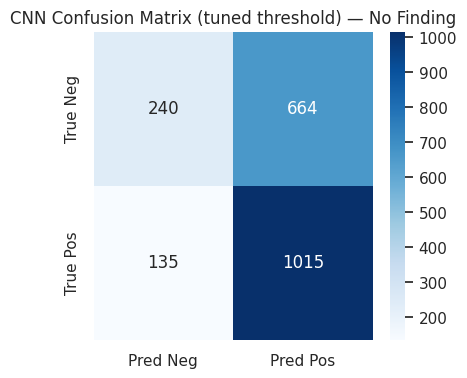

In [37]:
top_class_idx = int(np.argmax(y_test.sum(axis=0)))
top_class_name = mlb.classes_[top_class_idx]

cm = confusion_matrix(y_test[:, top_class_idx], cnn_pred_tuned[:, top_class_idx])
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Neg', 'Pred Pos'], yticklabels=['True Neg', 'True Pos'])
plt.title(f'CNN Confusion Matrix (tuned threshold) — {top_class_name}')
plt.show()

**Evaluation summary:** compare the `0.5 threshold` vs `tuned thresholds` rows for each
model above. If tuned thresholds materially raise macro-F1/recall on rare classes without
collapsing precision, that confirms threshold tuning was worthwhile; the models were learning
*something* about rare classes that a flat 0.5 cutoff was simply discarding. If tuned
thresholds barely move the needle, that points to the more fundamental limitation flagged in
section 11: at 96x96 resolution with a data subset and a handful of training epochs, there may not be
much class-discriminating signal being learned in the first place. In that case the lever to
pull next is scale (more data, higher resolution, a pretrained backbone), not thresholding.


## 11. Task 12 — Conclusions, Actionable Insights & Recommendations <a id="11"></a>

### Summary of methodological choices
This pipeline addresses several methodological gaps common in chest X-ray ML workflows:
- **StandardScaler** is fit on the training split only to avoid data leakage.
- CNN class weights are passed through a custom weighted binary cross-entropy loss.
- The subset is a shuffled, patient-level random sample, not a sequential head().
- Metadata columns are explicitly explored, then dropped with justification.
- Per-class thresholds are tuned on a held-out validation split.
- An explicit nested, patient-grouped train/validation/test split is used.

### Actionable insights
1. **Report macro-averaged metrics, not accuracy** - `No Finding` prevalence (~54-65% depending
   on sampling) makes accuracy meaningless on its own.
2. **`View Position` is a real confound**, not just a covariate - Cardiomegaly prevalence
   differs measurably between `AP` and `PA`, consistent with the known pseudo-cardiomegaly
   artifact of portable imaging.
3. **Always split by `Patient ID`**, and do so at every level (train/val/test, and every CV
   fold) - repeat patients make row-level or even naive train/test splits leak information.
4. **A fixed 0.5 threshold on imbalanced sigmoid outputs is not a neutral default** - it
   silently zeroes out rare-class predictions. Threshold tuning on a held-out validation split
   is a cheap, high-leverage fix worth doing before concluding a model "doesn't work."
5. **Scanner/acquisition metadata (`OriginalImage[Width,Height]`, `PixelSpacing[x,y]`) carries
   negligible clinical signal** and was correctly excluded - a reminder to test, not assume,
   whether "available" columns are actually informative.

### Recommendations for further work
- Train on the **full dataset**, not a 10k-row subset - rare classes need far more examples
  than a small subset can offer.
- Increase resolution toward **224x224** and use a **pretrained ImageNet backbone**
  (e.g. DenseNet-121, as in the original CheXNet study) - at 96x96 a small nodule or subtle
  infiltrate is only a few pixels and much of the diagnostic signal is lost to downsampling.
- Add **data augmentation** (rotation, brightness/contrast jitter) given exposure variability
  across scanners.
- Consider **focal loss** in addition to/instead of static positive-class weighting for the
  rarest classes.
- Pair any deployed model with **Grad-CAM or similar explainability tooling** so clinicians can
  audit which image regions drove a prediction.

### Limitations (stated plainly)
- Performance on this subset/resolution/epoch budget should be
  expected to be modest - the pipeline addresses correctness and methodology, not the fundamental
  compute/data-scale ceiling of a Colab-T4 demo.
- Labels in the NIH dataset are NLP-mined from radiology reports, not expert re-annotated, and
  carry known label noise - a caveat for any performance claim regardless of pipeline quality.
